# Logistic Regression

Logistic Regression is a parametric statistical model primarily used for binary and multi-class classification tasks.

**How It Works:**

It fits a linear combination of input features and passes the result through a non-linear activation function to map predicted outputs into continuous probabilities between 0 and 1.

* **Binary Classification:** Classifies inputs into Class 1 if the output probability exceeds a threshold (typically 0.5), and Class 0 otherwise.
* **Multi-Class Classification:** Uses One-vs-Rest (OvR) or Multinomial (Softmax) extensions to handle multiple class outputs.

**Best Use Cases:**

* Baseline classification tasks where the target is binary (e.g., Spam vs. Not Spam, Fraud vs. Legitimate).
* Applications requiring probability scores alongside final predicted class labels.

In [1]:
import pandas as pd

data = {'miles_per_week': [37,39,46,51,88,17,18,20,21,22,23,24,25,27,28,29,30,31,32,33,34,38,40,42,57,68,35,36,41,43,45,47,49,50,52,53,54,55,56,58,59,60,61,63,64,65,66,69,70,72,73,75,76,77,78,80,81,82,83,84,85,86,87,89,91,92,93,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,113,114,115,116,116,118,119,120,121,123,124,126,62,67,74,79,90,112],
      'completed_50m_ultra': ['no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','yes','yes','yes','yes','no','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes',]}

df = pd.DataFrame(data)
df.head()

,miles_per_week,completed_50m_ultra
0,37,no
1,39,no
2,46,no
3,51,no
4,88,no


In [2]:
from sklearn.preprocessing import OrdinalEncoder

finished_race = ['no','yes']

In [3]:
oe = OrdinalEncoder(categories=[finished_race])

In [4]:
df['completed_50m_ultra'] = oe.fit_transform(df[['completed_50m_ultra']])

In [5]:
df.head()

,miles_per_week,completed_50m_ultra
0,37,0.0
1,39,0.0
2,46,0.0
3,51,0.0
4,88,0.0


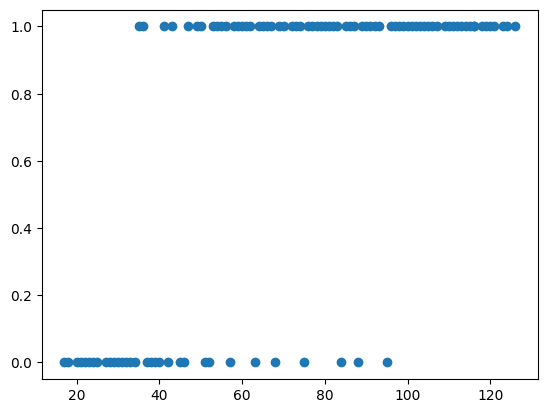

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df.miles_per_week, df.completed_50m_ultra)

<Axes: xlabel='completed_50m_ultra', ylabel='count'>

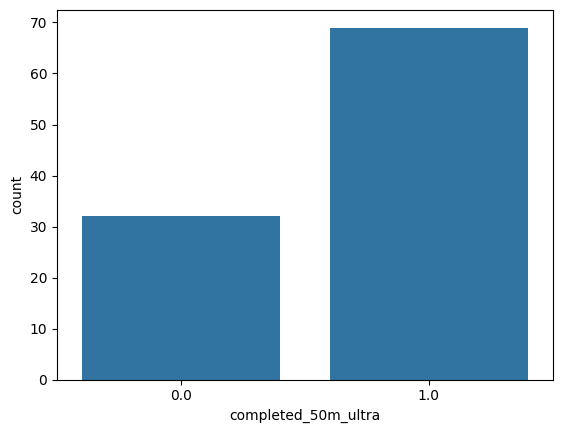

In [7]:
import seaborn as sns

sns.countplot(x='completed_50m_ultra', data=df)

In [9]:
X = df.iloc[:, 0:1]
y = df.iloc[:,1]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=11, test_size=0.2)

In [11]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

logreg.fit(X_train,y_train)

y_pred = logreg.predict(X_test)


In [12]:
logreg.score(X_test, y_test)

0.9047619047619048

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_test, y_pred)

array([[ 5,  1],
       [ 1, 14]])

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.93      0.93      0.93        15

    accuracy                           0.90        21
   macro avg       0.88      0.88      0.88        21
weighted avg       0.90      0.90      0.90        21

